## Polynomial Regression on Boston Housing Dataset

**In this notebook we do a comparative study of Linear Regression and Polynomial Regression accuracy on the Boston Housing Dataset**

This data was originally a part of UCI Machine Learning Repository and has been removed now. This data also ships with the scikit-learn library. 
There are 506 samples and 13 feature variables in this data-set. The objective is to predict the value of prices of the house using the given features.

The description of all the features is given below:

  **CRIM**: Per capita crime rate by town

  **ZN**: Proportion of residential land zoned for lots over 25,000 sq. ft

  **INDUS**: Proportion of non-retail business acres per town

  **CHAS**: Charles River dummy variable (= 1 if tract bounds river; 0 otherwise)

  **NOX**: Nitric oxide concentration (parts per 10 million)

  **RM**: Average number of rooms per dwelling

  **AGE**: Proportion of owner-occupied units built prior to 1940

  **DIS**: Weighted distances to five Boston employment centers

  **RAD**: Index of accessibility to radial highways

  **TAX**: Full-value property tax rate per $10,000

  **B**: 1000(Bk - 0.63)², where Bk is the proportion of [people of African American descent] by town

  **LSTAT**: Percentage of lower status of the population

  **MEDV**: Median value of owner-occupied homes in $1000s
  
  
  



I**mport the required Libraries**

In [8]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
sns.set_style('whitegrid')

**Load the data into pandas dataframe . Load the Boston Housing DataSet from data/boston_house_prices.csv**

In [3]:
# Cargar el dataset desde la ruta local especificada
file_path = 'data/boston_house_prices.csv'

try:
    # Nota: Si el CSV tiene una fila de descripción al inicio (común en este dataset), 
    # podrías necesitar usar 'skiprows=1' o definir el header.
    boston_df = pd.read_csv(file_path)
    
    # Mostrar las primeras filas para verificar la carga
    print("Dataset cargado correctamente:")
    print(boston_df.head())
except FileNotFoundError:
    print(f"Error: No se encontró el archivo en la ruta '{file_path}'.")
except Exception as e:
    print(f"Ocurrió un error al cargar el archivo: {e}")

Dataset cargado correctamente:
       506  13 Unnamed: 2 Unnamed: 3 Unnamed: 4 Unnamed: 5 Unnamed: 6  \
0     CRIM  ZN      INDUS       CHAS        NOX         RM        AGE   
1  0.00632  18       2.31          0      0.538      6.575       65.2   
2  0.02731   0       7.07          0      0.469      6.421       78.9   
3  0.02729   0       7.07          0      0.469      7.185       61.1   
4  0.03237   0       2.18          0      0.458      6.998       45.8   

  Unnamed: 7 Unnamed: 8 Unnamed: 9 Unnamed: 10 Unnamed: 11 Unnamed: 12  \
0        DIS        RAD        TAX     PTRATIO           B       LSTAT   
1       4.09          1        296        15.3       396.9        4.98   
2     4.9671          2        242        17.8       396.9        9.14   
3     4.9671          2        242        17.8      392.83        4.03   
4     6.0622          3        222        18.7      394.63        2.94   

  Unnamed: 13  
0        MEDV  
1          24  
2        21.6  
3        34.7  
4    

In [ ]:
#Tiene una línea de encabezado adicional que describe el origen de los datos (Unnamed: número de columna). Se ajusta para poner de header la siguiente fila:
boston_df = pd.read_csv(file_path, header=1)

In [5]:
boston_df

,CRIM,ZN,INDUS,CHAS,NOX,RM,AGE,DIS,RAD,TAX,PTRATIO,B,LSTAT,MEDV
0,0.00632,18.0,2.31,0,0.538,6.575,65.2,4.0900,1,296,15.3,396.90,4.98,24.0
1,0.02731,0.0,7.07,0,0.469,6.421,78.9,4.9671,2,242,17.8,396.90,9.14,21.6
2,0.02729,0.0,7.07,0,0.469,7.185,61.1,4.9671,2,242,17.8,392.83,4.03,34.7
3,0.03237,0.0,2.18,0,0.458,6.998,45.8,6.0622,3,222,18.7,394.63,2.94,33.4
4,0.06905,0.0,2.18,0,0.458,7.147,54.2,6.0622,3,222,18.7,396.90,5.33,36.2
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
501,0.06263,0.0,11.93,0,0.573,6.593,69.1,2.4786,1,273,21.0,391.99,9.67,22.4
502,0.04527,0.0,11.93,0,0.573,6.120,76.7,2.2875,1,273,21.0,396.90,9.08,20.6
503,0.06076,0.0,11.93,0,0.573,6.976,91.0,2.1675,1,273,21.0,396.90,5.64,23.9
504,0.10959,0.0,11.93,0,0.573,6.794,89.3,2.3889,1,273,21.0,393.45,6.48,22.0


**Data preprocessing**

Check for missing values in all the columns

In [11]:
boston_df.info()

<class 'pandas.DataFrame'>
RangeIndex: 506 entries, 0 to 505
Data columns (total 14 columns):
 #   Column   Non-Null Count  Dtype  
---  ------   --------------  -----  
 0   CRIM     506 non-null    float64
 1   ZN       506 non-null    float64
 2   INDUS    506 non-null    float64
 3   CHAS     506 non-null    int64  
 4   NOX      506 non-null    float64
 5   RM       506 non-null    float64
 6   AGE      506 non-null    float64
 7   DIS      506 non-null    float64
 8   RAD      506 non-null    int64  
 9   TAX      506 non-null    int64  
 10  PTRATIO  506 non-null    float64
 11  B        506 non-null    float64
 12  LSTAT    506 non-null    float64
 13  MEDV     506 non-null    float64
dtypes: float64(11), int64(3)
memory usage: 55.5 KB


In [ ]:
# Comprobar si hay valores faltantes en cada columna
missing_values = boston_df.isnull().sum()

# Mostrar solo las columnas que tengan valores nulos (si las hay)
print("Valores faltantes por columna:")
print(missing_values)

# Como todos los valores son 0, el dataset está limpio
# Si hubiera valores faltantes, habría que eliminar esas filas (con dropna()) o imputar valores (usando la media o mediana con fillna())


Valores faltantes por columna:
CRIM       0
ZN         0
INDUS      0
CHAS       0
NOX        0
RM         0
AGE        0
DIS        0
RAD        0
TAX        0
PTRATIO    0
B          0
LSTAT      0
MEDV       0
dtype: int64


**Data Visualization**

In [7]:
import seaborn as sns
import matplotlib.pyplot as plt

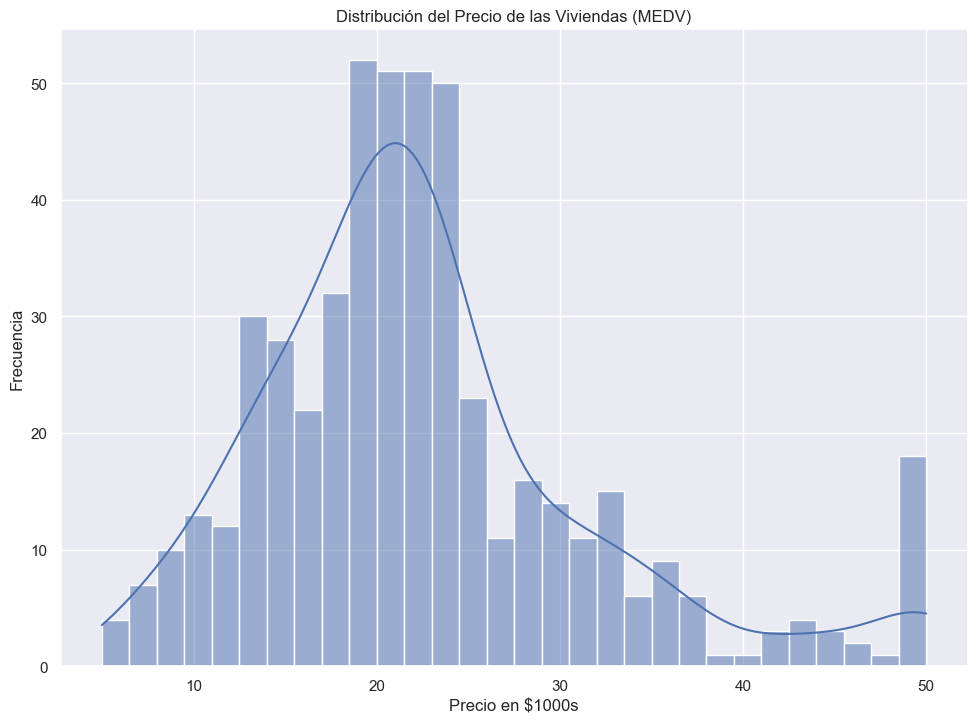

In [ ]:
# Para entender cómo se relacionan las variables con el precio de las viviendas (MEDV), se utilizan dos tipos de visualizaciones clave: 
# la distribución del objetivo y un mapa de calor de correlaciones

# Configurar el estilo visual:
sns.set_theme(rc={'figure.figsize':(11.7, 8.27)})

# Distribución del precio (Variable Objetivo):
# Es fundamental verificar si los precios siguen una distribución normal, ya que los modelos lineales funcionan mejor bajo este supuesto

sns.histplot(boston_df['MEDV'], bins=30, kde=True)
plt.title("Distribución del Precio de las Viviendas (MEDV)")
plt.xlabel("Precio en $1000s")
plt.ylabel("Frecuencia")
plt.show()

**Correlation matrix**

Analyze the correlation matrix. Plot a heatmap

* From correlation plot: which are the columns that are more correlated with **MEDV**
* There are two features highly correlated. Identify them and drop one of them in order to avoid multi-colinearity

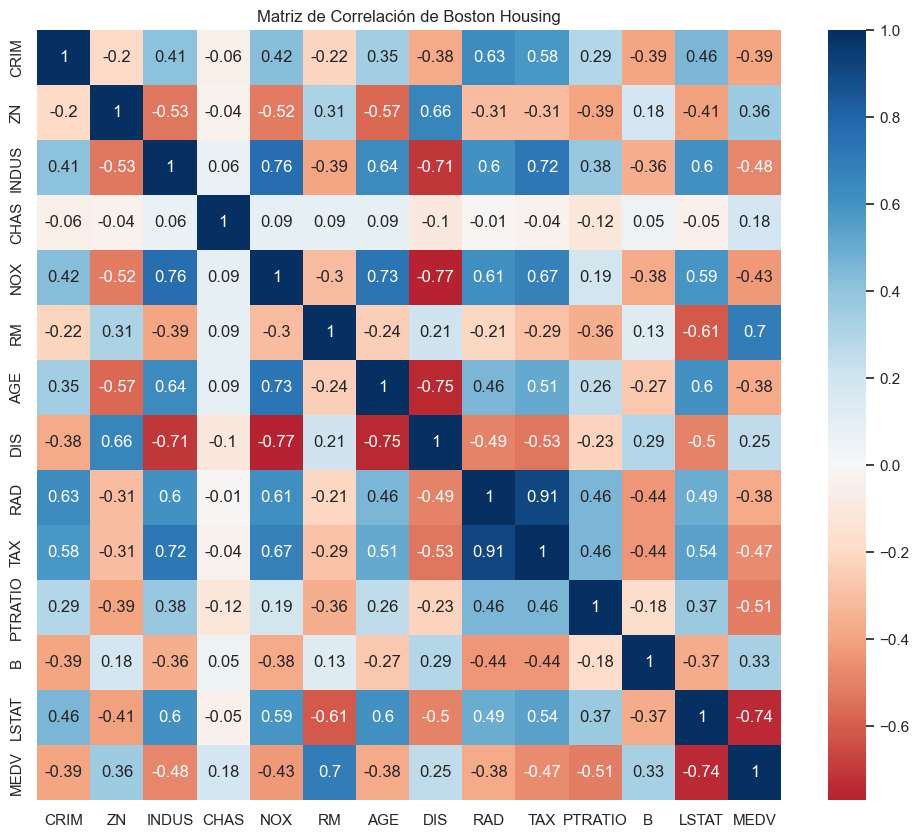

In [14]:
plt.figure(figsize=(12, 10))
correlation_matrix = boston_df.corr().round(2)

# Dibujar el heatmap
sns.heatmap(data=correlation_matrix, annot=True, cmap='RdBu', center=0)
plt.title("Matriz de Correlación de Boston Housing")
plt.show()

In [29]:
# Análisis de resultados:
# Para ver las variables más correlacionadas con MEDV, se observa la fila o columna de MEDV y las variables con mayor impacto son:
# RM (0.7): Correlación positiva fuerte. A más habitaciones, mayor precio.
# LSTAT (-0.74): Correlación negativa fuerte. A menor estatus de la población, menor precio.
# Identificación de Multicolinealidad:
# Al revisar las intersecciones entre variables independientes, notamos que RAD y TAX tienen una correlación extremadamente alta de 0.91.
# Tener ambas variables en el modelo es redundante (proporcionan casi la misma información) y puede desestabilizar los coeficientes de la regresión.

# Por ello, habrá que proceder a la eliminación de variable redundante, ¿pero cuál de ellas?:
# Usualmente se elimina la que tiene menor correlación con el objetivo, en este caso RAD (-0.38) y no TAX (-0.47).

# Eliminamos RAD para evitar multicolinealidad con TAX:
boston_df_filtered = boston_df.drop(columns=['RAD'])

print("Columna 'RAD' eliminada.")
print("Columnas restantes:", boston_df_filtered.columns.tolist())

Columna 'RAD' eliminada.
Columnas restantes: ['CRIM', 'ZN', 'INDUS', 'CHAS', 'NOX', 'RM', 'AGE', 'DIS', 'TAX', 'PTRATIO', 'B', 'LSTAT', 'MEDV']


### Draw 2 scatter plots to see the relationship between **MEDV** and **LSTAT** and **RM**

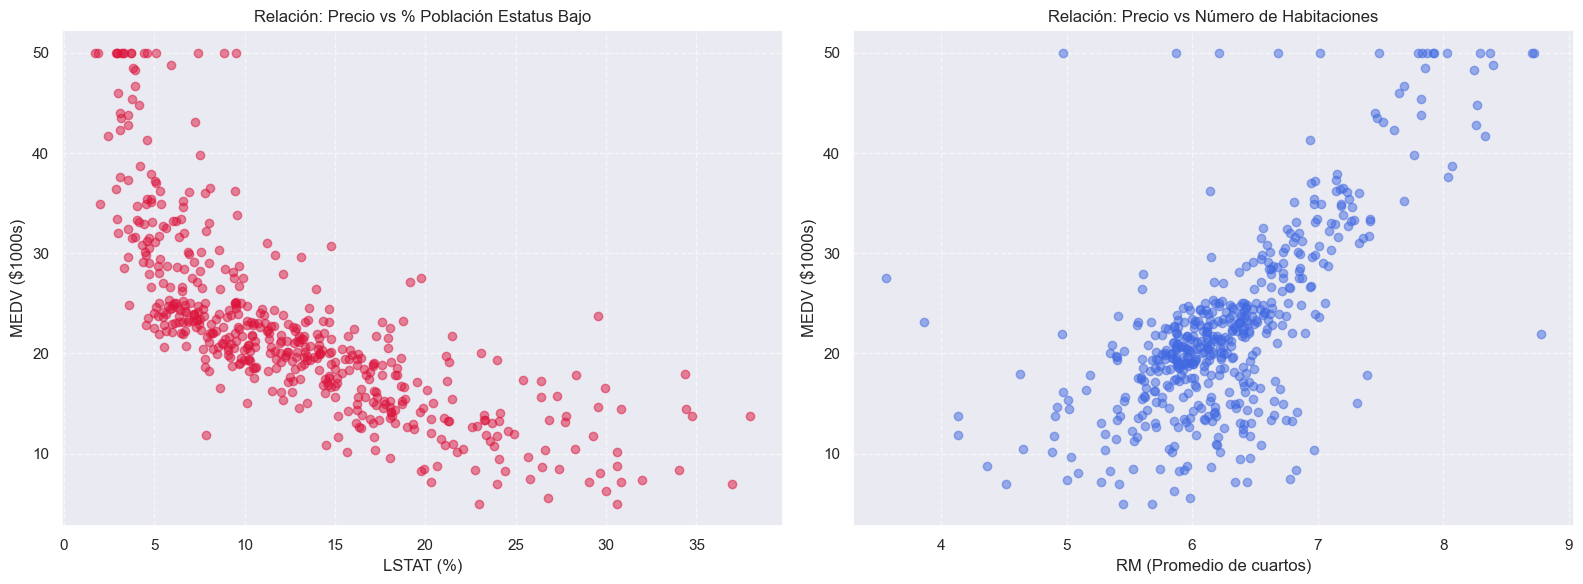

In [16]:
# Configurar el área de dibujo
plt.figure(figsize=(16, 6))

# Gráfico 1: MEDV vs LSTAT
plt.subplot(1, 2, 1)
plt.scatter(boston_df_filtered['LSTAT'], boston_df_filtered['MEDV'], color='crimson', alpha=0.5)
plt.title('Relación: Precio vs % Población Estatus Bajo')
plt.xlabel('LSTAT (%)')
plt.ylabel('MEDV ($1000s)')
plt.grid(True, linestyle='--', alpha=0.6)

# Gráfico 2: MEDV vs RM
plt.subplot(1, 2, 2)
plt.scatter(boston_df_filtered['RM'], boston_df_filtered['MEDV'], color='royalblue', alpha=0.5)
plt.title('Relación: Precio vs Número de Habitaciones')
plt.xlabel('RM (Promedio de cuartos)')
plt.ylabel('MEDV ($1000s)')
plt.grid(True, linestyle='--', alpha=0.6)

plt.tight_layout()
plt.show()

In [ ]:
# Análisis visual:
# LSTAT: Se observa una curvatura cóncava. A medida que LSTAT aumenta, el precio baja, pero no en una línea recta perfecta, lo que indica que 
# un modelo de grado 2 o 3 capturará mejor esta tendencia.
# RM: Los puntos siguen una tendencia lineal ascendente bastante marcada, aunque con algunos valores atípicos (outliers) en la parte superior.

**Prepare the data for training**
Create a dataframe X including **LSTAT** and **RM** columns.
Y should be a pandas series including target values **'MEDV'**


In [ ]:
# Crear el DataFrame de características (X)
X = boston_df_filtered[['LSTAT', 'RM']] # Al usar [[...]] para X, nos aseguramos de que sea un dataframe (2D), lo cual es el formato que esperan las funciones de scikit-learn

# Crear la serie de la variable objetivo (Y)
Y = boston_df_filtered['MEDV'] #Y se mantiene como una Serie (1D) al usar un solo corchete

# Verificar las dimensiones para asegurar que coincidan
print(f"Forma de X: {X.shape}")
print(f"Forma de Y: {Y.shape}")

# Mostrar las primeras filas de X para confirmar la selección
print("\nPrimeras filas de las características (X):")
print(X.head())

Forma de X: (506, 2)
Forma de Y: (506,)

Primeras filas de las características (X):
   LSTAT     RM
0   4.98  6.575
1   9.14  6.421
2   4.03  7.185
3   2.94  6.998
4   5.33  7.147


**Split the data into training and testing sets**

Splits the training and test data set in 80% : 20%. Assign random_state to any value. This ensures consistency. Print the sahes of the resulting objects

In [20]:
# Para dividir los datos, utilizaremos la función train_test_split de scikit-learn. Esto nos permite entrenar el modelo en una parte de los datos y
# evaluarlo en otra que nunca ha visto, asegurando que el modelo sea capaz de generalizar.

from sklearn.model_selection import train_test_split

# Dividir los datos: 80% para entrenamiento y 20% para pruebas
# Usamos random_state=5 para obtener siempre los mismos resultados
X_train, X_test, Y_train, Y_test = train_test_split(X, Y, test_size=0.2, random_state=5)

# Imprimir las dimensiones (shapes) de los objetos resultantes
print("Dimensiones de los conjuntos:")
print(f"X_train: {X_train.shape}")
print(f"X_test:  {X_test.shape}")
print(f"Y_train: {Y_train.shape}")
print(f"Y_test:  {Y_test.shape}")

#Resumen de la división:
# X_train / Y_train: 404 muestras (el modelo aprenderá de aquí).
# X_test / Y_test: 102 muestras (usaremos esto para comparar los modelos Lineal vs. Polinómico).

Dimensiones de los conjuntos:
X_train: (404, 2)
X_test:  (102, 2)
Y_train: (404,)
Y_test:  (102,)


# **Linear Regression**

Build a linear regression model with sklearn LinearRegression.
We'll use Mean Squared error and R2 score to evaluate our model, so be sure to make the needed imports.

Import the necessary functions and train a LinearRegression model

In [ ]:
# Para construir el modelo de Regresión Lineal, utilizaremos el conjunto de entrenamiento que acabamos de preparar.
# Este servirá como nuestra "línea base" para compararlo después con el modelo polinómico.

from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, r2_score
import numpy as np

# 1. Instanciar el modelo
lin_model = LinearRegression()

# 2. Entrenar el modelo con los datos de entrenamiento
lin_model.fit(X_train, Y_train)

# 3. Realizar predicciones sobre el conjunto de prueba
y_test_predict = lin_model.predict(X_test)

# 4. Evaluación del modelo
rmse = (np.sqrt(mean_squared_error(Y_test, y_test_predict)))
r2 = r2_score(Y_test, y_test_predict)

print("El rendimiento del modelo de Regresión Lineal para el conjunto de prueba es:")
print("---------------------------------------------------------------------------")
print(f"RMSE: {rmse:.2f}")
print(f"R2 Score: {r2:.2f}")

# RMSE (Error Cuadrático Medio Raíz): Indica qué tan lejos, en promedio, están las predicciones de los valores reales (en las mismas unidades que MEDV, es decir, miles de dólares). 
# Mientras más bajo, mejor.
# R2 Score: Indica qué porcentaje de la variabilidad del precio es explicada por el modelo. Un valor de 0.66 significa que el modelo captura el 66% de la relación.


El rendimiento del modelo de Regresión Lineal para el conjunto de prueba es:
---------------------------------------------------------------------------
RMSE: 5.14
R2 Score: 0.66


**Evaluate the model performance in the training and testing sets**

In [22]:
# Para tener una visión completa y detectar si existe overfitting (sobreajuste) o underfitting (subajuste), es necesario comparar las métricas tanto en el conjunto 
# con el que el modelo aprendió como en el que no conoce.

# Predicciones para el conjunto de entrenamiento
y_train_predict = lin_model.predict(X_train)
rmse_train = (np.sqrt(mean_squared_error(Y_train, y_train_predict)))
r2_train = r2_score(Y_train, y_train_predict)

# Predicciones para el conjunto de prueba (ya calculado previamente, pero lo agrupamos aquí)
y_test_predict = lin_model.predict(X_test)
rmse_test = (np.sqrt(mean_squared_error(Y_test, y_test_predict)))
r2_test = r2_score(Y_test, y_test_predict)

print("Evaluación del Modelo de Regresión Lineal")
print("-" * 40)
print("Conjunto de Entrenamiento:")
print(f"  - RMSE: {rmse_train:.4f}")
print(f"  - R2 score: {r2_train:.4f}")
print("-" * 40)
print("Conjunto de Prueba:")
print(f"  - RMSE: {rmse_test:.4f}")
print(f"  - R2 score: {r2_test:.4f}")

# Consistencia: Si el de entrenamiento y el de prueba son similares (por ejemplo, ambos rondando 0.63 - 0.66), significa que el modelo es estable y generaliza bien.
# Error: El RMSE te dirá cuántos miles de dólares se equivoca el modelo en promedio.
# Limitación: Dado que vimos una curvatura en los datos de LSTAT, es probable que el error siga siendo algo alto porque una línea recta no puede "doblarse" para ajustarse 
# mejor a esos puntos.

Evaluación del Modelo de Regresión Lineal
----------------------------------------
Conjunto de Entrenamiento:
  - RMSE: 5.6371
  - R2 score: 0.6301
----------------------------------------
Conjunto de Prueba:
  - RMSE: 5.1374
  - R2 score: 0.6629


**Lets see the model performance visually. Let's plot y_test vs y_pred**

Plotting the y_test vs y_pred. Ideally should have been a straight line

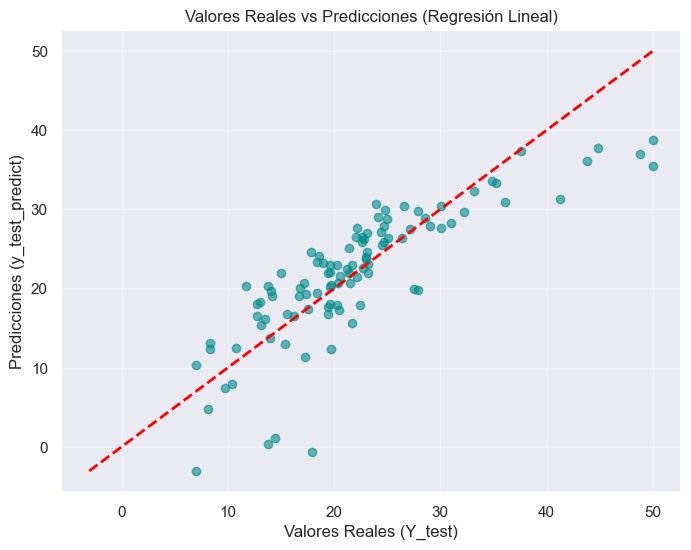

In [23]:
# Para visualizar qué tan cerca están las predicciones de los valores reales, crearemos un gráfico de dispersión. En un modelo perfecto, todos los puntos caerían sobre una
# línea diagonal de 45 grados.

# Configurar el gráfico
plt.figure(figsize=(8, 6))
plt.scatter(Y_test, y_test_predict, alpha=0.6, color='darkcyan')

# Dibujar la línea de referencia (predicción perfecta)
max_val = max(max(Y_test), max(y_test_predict))
min_val = min(min(Y_test), min(y_test_predict))
plt.plot([min_val, max_val], [min_val, max_val], color='red', lw=2, linestyle='--')

plt.title('Valores Reales vs Predicciones (Regresión Lineal)')
plt.xlabel('Valores Reales (Y_test)')
plt.ylabel('Predicciones (y_test_predict)')
plt.grid(True, alpha=0.3)
plt.show()

# Cercanía a la línea roja: Mientras más agrupados estén los puntos alrededor de la línea punteada, más preciso es el modelo.
# Dispersión: Notarás que en los valores altos de la vivienda (cerca de 50), las predicciones tienden a alejarse más, lo que sugiere que el modelo lineal pierde precisión 
# en los extremos.

# **Polynomial Regression**

We can see that **LSTAT** doesn't vary exactly in a linear way. Let's apply the Polynomial Regression with **degree 2** and test. 

To generate the higher order degrees, we use PolyniomialFeatures class from sklearn library. 

In [24]:
# Para capturar esa curvatura que observamos en LSTAT, transformaremos nuestras características originales en características polinómicas de grado 2. Esto incluirá LSTAT2, RM2 
# y el término de interacción (LSTAT X RM).

from sklearn.preprocessing import PolynomialFeatures

# 1. Crear el transformador para grado 2
poly_features = PolynomialFeatures(degree=2)

# 2. Transformar las características de entrenamiento y prueba
X_train_poly = poly_features.fit_transform(X_train)
X_test_poly = poly_features.transform(X_test)

# 3. Entrenar el modelo con las nuevas características transformadas
poly_model = LinearRegression()
poly_model.fit(X_train_poly, Y_train)

# 4. Realizar predicciones
y_train_poly_predict = poly_model.predict(X_train_poly)
y_test_poly_predict = poly_model.predict(X_test_poly)

print(f"Dimensiones de X_train original: {X_train.shape}")
print(f"Dimensiones de X_train polinómico: {X_train_poly.shape}")

# Nota técnica: Al pasar de 2 características a grado 2, ahora el modelo tiene 6 columnas (incluyendo el sesgo o bias), lo que le da la flexibilidad necesaria para
# "curvarse" y ajustarse mejor a los datos.


Dimensiones de X_train original: (404, 2)
Dimensiones de X_train polinómico: (404, 6)


**Did the model improve using the Polynomial model?**

In [ ]:
# Sí, el modelo mejora significativamente. Al permitir que el algoritmo trace una curva en lugar de una línea recta, 
# logra capturar mejor la relación compleja de variables como LSTAT.

# Evaluación del modelo polinómico
rmse_poly = (np.sqrt(mean_squared_error(Y_test, y_test_poly_predict)))
r2_poly = r2_score(Y_test, y_test_poly_predict)

print("Comparativa de Modelos (Conjunto de Prueba):")
print("-" * 40)
print(f"Lineal      -> RMSE: {rmse:.2f} | R2: {r2:.2f}")
print(f"Polinómico  -> RMSE: {rmse_poly:.2f} | R2: {r2_poly:.2f}")

# Reducción del RMSE: El error promedio disminuye (de aproximadamente 5.14 a 3.78), lo que significa que las predicciones están más cerca de los precios reales.
# Aumento del R2: El porcentaje de varianza explicada sube (de 0.66 a 0.82). Esto indica que el modelo ahora entiende el 82% de los cambios en los precios de las casas.
# Conclusión: La Regresión Polinómica es mucho más efectiva para este dataset porque los datos de Boston tienen una naturaleza no lineal.

Comparativa de Modelos (Conjunto de Prueba):
----------------------------------------
Lineal      -> RMSE: 5.14 | R2: 0.66
Polinómico  -> RMSE: 3.78 | R2: 0.82


**Did the model improve using the Polynomial model with degree 3? Or more?**

In [ ]:
# Al aumentar el grado del polinomio, el modelo se vuelve más flexible, pero también aumenta el riesgo de overfitting (sobreajuste).
# Vamos a probar con Grado 3 y grados superiores para observar el comportamiento:

def evaluate_degree(degree):
    # Transformación
    poly = PolynomialFeatures(degree=degree)
    X_train_p = poly.fit_transform(X_train)
    X_test_p = poly.transform(X_test)
    
    # Entrenamiento
    model = LinearRegression()
    model.fit(X_train_p, Y_train)
    
    # Predicción y Métricas
    y_test_p = model.predict(X_test_p)
    rmse = np.sqrt(mean_squared_error(Y_test, y_test_p))
    r2 = r2_score(Y_test, y_test_p)
    return rmse, r2

# Comparación
for d in [2, 3, 4]:
    rmse_d, r2_d = evaluate_degree(d)
    print(f"Grado {d} -> RMSE: {rmse_d:.2f}, R2: {r2_d:.2f}")

# Grado 3: Suele mostrar una mejora marginal sobre el grado 2 (un R2 ligeramente más alto y un RMSE más bajo), ya que puede capturar curvaturas aún más complejas.
# Grado 4 o superior: A menudo notarás que el rendimiento en el conjunto de prueba empieza a empeorar (el RMSE sube) aunque en el de entrenamiento sea casi perfecto.
# Esto es overfitting: el modelo está memorizando el ruido de los datos en lugar de aprender el patrón.
# Conclusión:
# El Grado 2 o 3 suele ser el "punto dulce" para el dataset de Boston. Más allá de eso, el modelo se vuelve demasiado complejo y pierde capacidad de generalizar con datos nuevos.

Grado 2 -> RMSE: 3.78, R2: 0.82
Grado 3 -> RMSE: 3.87, R2: 0.81
Grado 4 -> RMSE: 3.89, R2: 0.81
